# Week 4 — Deterministic & Multi-Objective MILP Block Scheduling

### Objectives
1. Formulate the block-sequencing MILP (binary `y[block, period]`)
2. Solve the **NPV-only** deterministic problem with PuLP / CBC
3. Build the **NPV vs Throughput** Pareto frontier via ε-constraint (Tabesh et al. 2023)
4. Add a **third objective** (strip ratio) for a genuine 3-objective analysis
5. Summarise results in a KPI table with operational interpretation

### Mathematical Foundation

Let:
- $B$ = set of blocks $\{0, \ldots, N-1\}$, $\;T$ = set of periods $\{1, \ldots, 10\}$
- $y_{b,t} \in \{0,1\}$ = 1 if block $b$ is mined in period $t$
- $\delta_t = (1+r)^{-t}$ = discount factor, $r = 10\%$
- $v_b$ = expected NPV of block $b$ (from Week 2 Monte Carlo, \$M)
- $\tau_b$ = tonnage of block $b$ (kt)
- $g_b$ = ore grade of block $b$ (fraction)
- $O_b$ = ore indicator = 1 if $g_b \geq g_{cut}$, else 0
- $\text{SR}_b$ = strip ratio of block $b$

**Objective — maximise discounted NPV:**
$$\max \; Z_{NPV} = \sum_{t=1}^{T} \delta_t \sum_{b \in B} v_b \, y_{b,t}$$

**Subject to:**

*Each block mined exactly once:*
$$\sum_{t=1}^{T} y_{b,t} = 1 \quad \forall b \in B$$

*Mining-capacity bounds (kt):*
$$\underline{MC} \leq \sum_{b} \tau_b \, y_{b,t} \leq \overline{MC} \quad \forall t$$

*Processing-capacity bounds — ore throughput per period (kt ore):*
$$\underline{PC} \leq \sum_{b} \tau_b \cdot O_b \cdot y_{b,t} \leq \overline{PC} \quad \forall t$$

*Slope / precedence — predecessor block $p$ must be mined before or in same period as $b$:*
$$\sum_{t'=1}^{t} y_{p,t'} \geq \sum_{t'=1}^{t} y_{b,t'} \quad \forall p \in \text{pred}(b), \forall t$$

**Two-objective ε-constraint (Tabesh et al. 2023, §2.2)**

Fix a minimum per-period ore throughput floor $\varepsilon_k$ and maximise NPV:
$$\max Z_{NPV} \quad \text{s.t.} \quad \sum_{b} \tau_b \cdot O_b \cdot y_{b,t} \geq \varepsilon_k \quad \forall t$$

Sweeping $\varepsilon_k$ from loose (NPV-unconstrained) to tight (full plant utilisation)
traces the **NPV–Throughput Pareto frontier**.

**Third objective — minimise discounted strip ratio:**
$$\min \; Z_{SR} = \sum_{t} \delta_t \sum_{b} \text{SR}_b \, \tau_b \, y_{b,t}$$

## 0. Imports & Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
import warnings, time, os
warnings.filterwarnings('ignore')

import pulp
from pulp import lpSum, LpVariable, LpProblem, LpMaximize, LpMinimize, LpStatus, value

np.random.seed(42)
print('PuLP version :', pulp.__version__)
print('Solvers available:', pulp.listSolvers(onlyAvailable=True))

T               = 10          # scheduling periods
DISCOUNT_RATE   = 0.10        # 10% annual discount rate
CAPACITY_LO     = 0.70        # lower bound = 70% of average period tonnage
CAPACITY_HI     = 1.30        # upper bound = 130% of average period tonnage
PROC_LO         = 0.70        # processing lower bound fraction
PROC_HI         = 1.30        # processing upper bound fraction
GRADE_CUTOFF    = 0.50        # ore/waste cutoff grade (fraction)
N_PARETO_PTS    = 15          # number of ε-constraint sweep points
SOLVER_TIME_LIM = 120         # seconds per MILP solve

print(f'\nConfiguration: T={T}, r={DISCOUNT_RATE:.0%}, '
      f'capacity [{CAPACITY_LO:.0%}, {CAPACITY_HI:.0%}], '
      f'Pareto points={N_PARETO_PTS}')

PuLP version : 3.3.1
Solvers available: ['PULP_CBC_CMD']

Configuration: T=10, r=10%, capacity [70%, 130%], Pareto points=15


## 1. Load Data (from Weeks 2 & 3)

In [2]:
# Load block model with Monte Carlo NPV estimates
df = pd.read_csv('block_model_with_simulation.csv')
print(f'Block model : {df.shape[0]} blocks × {df.shape[1]} columns')

mc = np.load('monte_carlo_matrices.npz')
grade_matrix = mc['grade_matrix']
npv_matrix   = mc['npv_matrix']
print(f'Monte Carlo : {grade_matrix.shape[1]} scenarios per block')

blocks      = df['block_id'].tolist()
N           = len(blocks)
b_idx       = {bid: i for i, bid in enumerate(blocks)}

tonnage     = df['tonnage_kt'].values
grade       = df['ore_grade_pct'].values
strip_ratio = df['stripping_ratio'].values
npv_exp     = df['npv_expected'].values / 1e6   # $M
npv_std     = df['npv_std'].values / 1e6
z_level     = df['z'].values
slope_sc    = df['slope_constraint'].values
x_coord     = df['x'].values
y_coord     = df['y'].values

# Discount factors: disc[0] = 1/(1.1)^1, disc[9] = 1/(1.1)^10
disc = np.array([1/(1+DISCOUNT_RATE)**t for t in range(1, T+1)])

# Ore indicator: 1 if block meets cut-off grade
ore_indicator = np.where(grade >= GRADE_CUTOFF, 1, 0)

# Mining capacity bounds
avg_tonnage   = tonnage.sum() / T
MC_lo         = CAPACITY_LO * avg_tonnage
MC_hi         = CAPACITY_HI * avg_tonnage

# Processing (ore) capacity bounds
avg_throughput = (tonnage * ore_indicator).sum() / T
PC_lo          = PROC_LO * avg_throughput
PC_hi          = PROC_HI * avg_throughput

print(f'\nCapacity bounds  : [{MC_lo:,.0f}, {MC_hi:,.0f}] kt/period')
print(f'Throughput bounds: [{PC_lo:,.0f}, {PC_hi:,.0f}] kt ore/period')
print(f'Total NPV (undiscounted, expected): ${npv_exp.sum():.1f} M')
print(f'disc[0]={disc[0]:.4f}  disc[4]={disc[4]:.4f}  disc[9]={disc[9]:.4f}')

Block model : 500 blocks × 18 columns
Monte Carlo : 200 scenarios per block

Capacity bounds  : [17,578, 32,645] kt/period
Throughput bounds: [17,413, 32,338] kt ore/period
Total NPV (undiscounted, expected): $17036.3 M
disc[0]=0.9091  disc[4]=0.6209  disc[9]=0.3855


## 2. Build Precedence Constraints

### Slope Precedence Rule

A block at depth $z$ may only be mined **after all predecessor blocks at $z + 10\,\text{m}$**
within a lateral radius $R = \text{slope\_constraint} \times 50\,\text{m}$ have been mined.

$$\text{slope\_constraint} = 1 \Rightarrow 50\,\text{m radius};\quad
   \text{slope\_constraint} = 3 \Rightarrow 150\,\text{m radius}$$

In [3]:
BENCH_STEP = 10   # z spacing (m)
XY_STEP    = 50   # x,y grid spacing (m)

def build_precedence(df, bench_step=BENCH_STEP, xy_step=XY_STEP):
    prec = {}
    for i, row in df.iterrows():
        b_id    = row['block_id']
        z_b     = row['z']
        x_b, y_b = row['x'], row['y']
        radius  = row['slope_constraint'] * xy_step
        z_above = z_b + bench_step
        preds = df[
            (df['z'] == z_above) &
            (np.abs(df['x'] - x_b) <= radius) &
            (np.abs(df['y'] - y_b) <= radius)
        ]['block_id'].tolist()
        prec[b_id] = preds
    n_with  = sum(1 for v in prec.values() if v)
    avg_cnt = np.mean([len(v) for v in prec.values()])
    print(f'Precedence built: {n_with}/{len(df)} blocks have ≥1 predecessor '
          f'(mean {avg_cnt:.1f} predecessors/block)')
    return prec

prec = build_precedence(df)
total_pairs = sum(len(v) for v in prec.values())
print(f'Total precedence pairs: {total_pairs:,}')
print(f'Example — B0000 predecessors: {prec["B0000"]}')

Precedence built: 388/500 blocks have ≥1 predecessor (mean 2.7 predecessors/block)
Total precedence pairs: 1,327
Example — B0000 predecessors: ['B0005', 'B0035', 'B0328', 'B0435', 'B0487']


## 3. NPV-Only MILP (Deterministic)

Solve the single-objective NPV-maximisation problem.
This gives the **upper bound** on NPV and the reference schedule.

In [4]:
def solve_npv_only(blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
                   prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
                   time_limit=SOLVER_TIME_LIM, verbose=False):
    prob = LpProblem('NPV_Only_MILP', LpMaximize)
    y = LpVariable.dicts('y',
                         [(b, t) for b in blocks for t in range(1, T+1)],
                         cat='Binary')
    # Objective
    prob += lpSum(disc[t-1] * npv_exp[b_idx[b]] * y[b, t]
                  for b in blocks for t in range(1, T+1)), 'Discounted_NPV'
    # C1: each block mined exactly once
    for b in blocks:
        prob += lpSum(y[b, t] for t in range(1, T+1)) == 1, f'once_{b}'
    # C2: mining capacity
    for t in range(1, T+1):
        mv = lpSum(tonnage[b_idx[b]] * y[b, t] for b in blocks)
        prob += mv >= MC_lo, f'mc_lo_{t}'
        prob += mv <= MC_hi, f'mc_hi_{t}'
    # C3: processing capacity
    for t in range(1, T+1):
        tp = lpSum(tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y[b, t] for b in blocks)
        prob += tp >= PC_lo, f'pc_lo_{t}'
        prob += tp <= PC_hi, f'pc_hi_{t}'
    # C4: slope/precedence
    for b in blocks:
        for p in prec.get(b, []):
            for t in range(1, T+1):
                prob += (lpSum(y[p, t_] for t_ in range(1, t+1)) >=
                         lpSum(y[b, t_] for t_ in range(1, t+1))), f'prec_{b}_{p}_{t}'
    solver = pulp.PULP_CBC_CMD(msg=int(verbose), timeLimit=time_limit,
                               options=['--ratio', '0.005'])
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0
    status = LpStatus[prob.status]
    obj    = value(prob.objective) if prob.status == 1 else None
    sched = []
    for b in blocks:
        for t in range(1, T+1):
            if value(y[b, t]) is not None and value(y[b, t]) > 0.5:
                i = b_idx[b]
                sched.append({
                    'block_id'   : b,
                    'period'     : t,
                    'tonnage'    : tonnage[i],
                    'grade'      : grade[i],
                    'npv_exp'    : npv_exp[i],
                    'strip_ratio': strip_ratio[i],
                    'disc_npv'   : disc[t-1] * npv_exp[i],
                    'throughput' : tonnage[i] * ore_indicator[i],
                })
    return status, obj, pd.DataFrame(sched), elapsed

print('Solving NPV-only MILP (500 blocks, 10 periods)…')
print('  Expect 1–3 min with CBC at 0.5% MIP gap')
status_npv, obj_npv, sched_npv, t_npv = solve_npv_only(
    blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
    prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi
)
print(f'  Status         : {status_npv}')
print(f'  Discounted NPV : ${obj_npv:.2f} M')
print(f'  Solve time     : {t_npv:.1f} s')

Solving NPV-only MILP (500 blocks, 10 periods)…
  Expect 1–3 min with CBC at 0.5% MIP gap
  Status         : Optimal
  Discounted NPV : $11436.24 M
  Solve time     : 122.6 s


## 4. NPV-Only Schedule — Per-Period KPIs

In [5]:
period_kpi = sched_npv.groupby('period').agg(
    n_blocks   = ('block_id',    'count'),
    tonnage_kt = ('tonnage',     'sum'),
    throughput = ('throughput',  'sum'),
    disc_npv_M = ('disc_npv',    'sum'),
    avg_grade  = ('grade',       'mean'),
    avg_sr     = ('strip_ratio', 'mean'),
).reset_index()

period_kpi['cum_disc_npv_M'] = period_kpi['disc_npv_M'].cumsum()
period_kpi['util_pct']       = period_kpi['tonnage_kt'] / MC_hi * 100

print('NPV-Only Schedule — Per-Period KPIs')
print('=' * 90)
print(period_kpi.to_string(index=False, float_format=lambda x: f'{x:,.1f}'))
print('=' * 90)
print(f'Total discounted NPV : ${period_kpi["disc_npv_M"].sum():.2f} M')
print(f'Total throughput     : {period_kpi["throughput"].sum():,.0f} kt ore')
print(f'\nPer-period ore throughput (needed for Pareto sweep):')
for _, row in period_kpi.iterrows():
    print(f'  Period {row["period"]:2.0f}: {row["throughput"]:8,.0f} kt  ({row["util_pct"]:.1f}% mining util)')

NPV-Only Schedule — Per-Period KPIs
 period  n_blocks  tonnage_kt  throughput  disc_npv_M  avg_grade  avg_sr  cum_disc_npv_M  util_pct
      1        63    32,574.3    32,160.2     2,416.1        0.8     2.5         2,416.1      99.8
      2        66    32,327.3    32,327.3     1,905.5        0.8     2.6         4,321.6      99.0
      3        61    31,289.0    30,712.6     1,630.2        0.9     2.5         5,951.8      95.8
      4        63    32,592.7    32,076.0     1,489.1        0.8     2.6         7,440.9      99.8
      5        66    32,256.7    31,834.8     1,364.7        0.8     2.7         8,805.7      98.8
      6        37    18,391.3    18,391.3       681.5        0.8     2.5         9,487.2      56.3
      7        37    18,462.1    18,033.1       600.4        0.8     2.7        10,087.6      56.6
      8        37    17,718.4    17,718.4       539.6        0.8     2.4        10,627.2      54.3
      9        35    17,878.4    17,878.4       456.2        0.8     2.6 

## 5. Stage 2 — ε-Constraint: NPV vs Throughput Pareto Frontier


**ε-constraint formulation:**
$$\sum_{b} \tau_b \cdot O_b \cdot y_{b,t} \geq \varepsilon \quad \forall t \in \{1,\ldots,T\}$$

Sweeping $\varepsilon$ from $\varepsilon_{\min}$ (worst period in NPV-only schedule)
to $\varepsilon_{\max}$ (uniform full utilisation) traces the Pareto frontier.

In [ ]:
def solve_epsilon_constraint(blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
                              prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
                              eps_per_period, sr_epsilon=None,
                              time_limit=SOLVER_TIME_LIM):
    """
    ε-constraint MILP — per-period throughput floor.

    eps_per_period : minimum ore throughput required EVERY period (kt)
                     This is the correct second objective from Tabesh et al. (2023):
                     the NPV maximiser starves later periods; we force a floor.
    sr_epsilon     : if given, maximum discounted strip ratio (third objective)

    Returns: (status, npv_M, min_period_tp, avg_sr, solve_time)
    """
    prob = LpProblem('Epsilon_MILP', LpMaximize)
    y = LpVariable.dicts('y_eps',
                         [(b, t) for b in blocks for t in range(1, T+1)],
                         cat='Binary')

    # Objective: max discounted NPV
    prob += lpSum(disc[t-1] * npv_exp[b_idx[b]] * y[b, t]
                  for b in blocks for t in range(1, T+1))

    # C1: each block mined exactly once
    for b in blocks:
        prob += lpSum(y[b, t] for t in range(1, T+1)) == 1

    # C2: mining capacity
    for t in range(1, T+1):
        mv = lpSum(tonnage[b_idx[b]] * y[b, t] for b in blocks)
        prob += mv >= MC_lo
        prob += mv <= MC_hi

    # C3: processing capacity
    for t in range(1, T+1):
        tp = lpSum(tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y[b, t] for b in blocks)
        prob += tp >= PC_lo
        prob += tp <= PC_hi

    # C4: slope/precedence
    for b in blocks:
        for p in prec.get(b, []):
            for t in range(1, T+1):
                prob += (lpSum(y[p, t_] for t_ in range(1, t+1)) >=
                         lpSum(y[b, t_] for t_ in range(1, t+1)))

    #  ε-constraint on PER-PERIOD ore throughput 
    # Forces EVERY period to deliver at least eps_per_period kt of ore.
    # This genuinely conflicts with NPV-max which starves periods 6-10.
    for t in range(1, T+1):
        period_ore = lpSum(
            tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * y[b, t]
            for b in blocks
        )
        prob += period_ore >= eps_per_period, f'eps_tp_period_{t}'

    # C6 (optional): third-objective strip-ratio ceiling
    if sr_epsilon is not None:
        disc_sr = lpSum(disc[t-1] * strip_ratio[b_idx[b]] * tonnage[b_idx[b]] * y[b, t]
                        for b in blocks for t in range(1, T+1))
        prob += disc_sr <= sr_epsilon, 'eps_sr'

    solver = pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit,
                               options=['--ratio', '0.005'])  # 0.5% gap
    t0 = time.time()
    prob.solve(solver)
    elapsed = time.time() - t0

    if prob.status != 1:
        return LpStatus[prob.status], None, None, None, elapsed

    npv_val = value(prob.objective)

    # Compute per-period ore to report minimum (= how tight was the constraint)
    period_ore_vals = []
    for t in range(1, T+1):
        ore_t = sum(
            tonnage[b_idx[b]] * ore_indicator[b_idx[b]] * (value(y[b, t]) or 0)
            for b in blocks
            if value(y[b, t]) is not None and value(y[b, t]) > 0.5
        )
        period_ore_vals.append(ore_t)

    min_period_tp = min(period_ore_vals)
    avg_period_tp = np.mean(period_ore_vals)

    sr_val = sum(
        disc[t-1] * strip_ratio[b_idx[b]] * tonnage[b_idx[b]] * (value(y[b, t]) or 0)
        for b in blocks for t in range(1, T+1)
        if value(y[b, t]) is not None and value(y[b, t]) > 0.5
    )

    return 'Optimal', npv_val, avg_period_tp, sr_val, elapsed

In [ ]:
# Compute epsilon sweep range
#
# eps_min: the worst (lowest) per-period ore in the NPV-only schedule
#          — starting here means the first Pareto point = NPV-only solution
# eps_max: push toward uniform utilisation (avg per-period ore × 0.95)
#          — 0.95 buffer to avoid infeasibility at the tight end
#
per_period_ore = period_kpi.set_index('period')['throughput']
print('Per-period ore in NPV-only schedule (kt):')
for t, v in per_period_ore.items():
    print(f'  Period {t:2d}: {v:8,.0f} kt')

eps_min = per_period_ore.min()        # worst period — loose floor
eps_max = avg_throughput * 0.95       # near-uniform — tight floor

print(f'\nεmin (worst NPV-only period)   : {eps_min:,.0f} kt/period')
print(f'εmax (near-uniform target)     : {eps_max:,.0f} kt/period')
print(f'PC_lo (hard processing floor)  : {PC_lo:,.0f} kt/period')
print(f'Difference (sweep range)       : {eps_max - eps_min:,.0f} kt/period')

# Safety check: eps_max must be ≤ PC_hi, otherwise infeasible
if eps_max > PC_hi:
    eps_max = PC_hi * 0.95
    print(f'  → eps_max capped at {eps_max:,.0f} (95% of PC_hi)')

eps_range = np.linspace(eps_min, eps_max, N_PARETO_PTS)
print(f'\nSweeping {N_PARETO_PTS} epsilon values: [{eps_range[0]:,.0f} → {eps_range[-1]:,.0f}] kt/period')

Per-period ore in NPV-only schedule (kt):
  Period  1:   32,160 kt
  Period  2:   32,327 kt
  Period  3:   30,713 kt
  Period  4:   32,076 kt
  Period  5:   31,835 kt
  Period  6:   18,391 kt
  Period  7:   18,033 kt
  Period  8:   17,718 kt
  Period  9:   17,878 kt
  Period 10:   17,623 kt

εmin (worst NPV-only period)   : 17,623 kt/period
εmax (near-uniform target)     : 23,632 kt/period
PC_lo (hard processing floor)  : 17,413 kt/period
Difference (sweep range)       : 6,009 kt/period

Sweeping 15 epsilon values: [17,623 → 23,632] kt/period


In [ ]:
# Sanity check: run first and last epsilon before full sweep 
print('Sanity check — solving eps[0] and eps[-1] …\n')
for eps_k in [eps_range[0], eps_range[-1]]:
    st, npv_k, tp_k, sr_k, t_k = solve_epsilon_constraint(
        blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
        prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
        eps_per_period=eps_k
    )
    npv_str = f'{npv_k:.2f}' if npv_k is not None else 'INFEASIBLE'
    tp_str  = f'{tp_k:,.0f}' if tp_k  is not None else 'INFEASIBLE'
    print(f'  eps={eps_k:,.0f}  →  NPV={npv_str} $M,  avg_tp={tp_str} kt/period,  status={st},  t={t_k:.0f}s')

print('\nIf both status=Optimal and NPV values differ → frontier is real.')
print('If eps[-1] is INFEASIBLE → reduce eps_max (cell above).')

Sanity check — solving eps[0] and eps[-1] …

  eps=17,623  →  NPV=11450.60 $M,  avg_tp=24,875 kt/period,  status=Optimal,  t=122s
  eps=23,632  →  NPV=10721.25 $M,  avg_tp=24,875 kt/period,  status=Optimal,  t=122s

If both status=Optimal and NPV values differ → frontier is real.
If eps[-1] is INFEASIBLE → reduce eps_max (cell above).


In [ ]:
# Full Pareto sweep
print(f'Running {N_PARETO_PTS} Pareto-point solves…\n')
print(f'{"ε (kt/period)":>16}  {"NPV ($M)":>12}  {"Avg TP":>10}  {"Status":>12}  {"Time(s)":>8}')
print('-' * 68)

pareto_2obj = []
for k, eps_k in enumerate(eps_range):
    st, npv_k, tp_k, sr_k, t_k = solve_epsilon_constraint(
        blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
        prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
        eps_per_period=eps_k
    )
    marker   = '✓' if st == 'Optimal' else '✗'
    npv_str  = f'{npv_k:>12,.2f}' if npv_k is not None else f'{"infeasible":>12}'
    tp_str   = f'{tp_k:>10,.0f}'  if tp_k  is not None else f'{"-":>10}'
    print(f'  {eps_k:>14,.0f}  {npv_str}  {tp_str}  {st:>12}  {t_k:>7.0f}s  {marker}')
    if st == 'Optimal':
        pareto_2obj.append({
            'eps_per_period' : eps_k,
            'npv_M'          : npv_k,
            'avg_tp'         : tp_k,
            'strip_ratio_disc': sr_k,
            'solve_s'        : t_k
        })

pareto_df = pd.DataFrame(pareto_2obj).sort_values('avg_tp').reset_index(drop=True)
print(f'\n2-objective Pareto points obtained: {len(pareto_df)} / {N_PARETO_PTS}')
print(f'NPV range  : ${pareto_df["npv_M"].max():,.1f} M  →  ${pareto_df["npv_M"].min():,.1f} M')
print(f'TP range   : {pareto_df["avg_tp"].min():,.0f}  →  {pareto_df["avg_tp"].max():,.0f} kt/period')
npv_loss_pct = (pareto_df['npv_M'].max() - pareto_df['npv_M'].min()) / pareto_df['npv_M'].max() * 100
print(f'NPV cost of max throughput: {npv_loss_pct:.2f}%')

Running 15 Pareto-point solves…

   ε (kt/period)      NPV ($M)      Avg TP        Status   Time(s)
--------------------------------------------------------------------
          17,623     11,450.60      24,875       Optimal      122s  ✓
          18,052     11,406.32      24,875       Optimal      122s  ✓
          18,481     11,402.97      24,875       Optimal      122s  ✓
          18,910     11,378.52      24,875       Optimal      122s  ✓
          19,340     11,360.21      24,875       Optimal      122s  ✓
          19,769     11,349.82      24,875       Optimal      122s  ✓
          20,198     11,323.80      24,875       Optimal      123s  ✓
          20,627     11,289.98      24,875       Optimal      122s  ✓
          21,056     11,246.99      24,875       Optimal      122s  ✓
          21,486     11,222.23      24,875       Optimal      122s  ✓
          21,915     11,197.63      24,875       Optimal      126s  ✓
          22,344     11,144.85      24,875       Optimal     

## 6. Third Objective — Strip Ratio (Waste Intensity)

$$\min \; Z_{SR} = \sum_{t} \delta_t \sum_{b} \text{SR}_b \, \tau_b \, y_{b,t}$$

Fix throughput at 3 representative levels and sweep a strip-ratio upper bound
to generate the **3-objective Pareto surface** projection.

In [10]:
npv_star = pareto_df['npv_M'].max()
sr_max   = pareto_df['strip_ratio_disc'].max()
sr_min   = pareto_df['strip_ratio_disc'].min()

# 3 throughput levels: low / mid / high from 2-obj frontier
tp_levels = [pareto_df['eps_per_period'].quantile(q) for q in [0.20, 0.50, 0.80]]
sr_range  = np.linspace(sr_min * 1.02, sr_max * 0.98, 6)

print('3-objective sweep: fix throughput at 3 levels × 6 strip-ratio ε')
print(f'Throughput levels: {[f"{v:,.0f}" for v in tp_levels]} kt/period')
print(f'SR range         : [{sr_range[0]:,.0f}, {sr_range[-1]:,.0f}]')
print()

pareto_3obj = []
for tp_level in tp_levels:
    for sr_eps in sr_range:
        st, npv_k, tp_k, sr_k, t_k = solve_epsilon_constraint(
            blocks, N, tonnage, grade, ore_indicator, npv_exp, disc,
            prec, b_idx, T, MC_lo, MC_hi, PC_lo, PC_hi,
            eps_per_period=tp_level,
            sr_epsilon=sr_eps
        )
        if st == 'Optimal':
            pareto_3obj.append({
                'eps_tp'          : tp_level,
                'eps_sr'          : sr_eps,
                'npv_M'           : npv_k,
                'avg_tp'          : tp_k,
                'strip_ratio_disc': sr_k,
            })

pareto_3df = pd.DataFrame(pareto_3obj)
print(f'3-objective surface points: {len(pareto_3df)}')
if len(pareto_3df) > 0:
    print(pareto_3df.round(1).to_string(index=False))

3-objective sweep: fix throughput at 3 levels × 6 strip-ratio ε
Throughput levels: ['18,739', '20,413', '22,087'] kt/period
SR range         : [406,759, 412,509]

3-objective surface points: 18
 eps_tp   eps_sr   npv_M  avg_tp  strip_ratio_disc
18738.7 406759.3 11264.2 24875.5          406748.8
18738.7 407909.2 11291.7 24875.5          407840.7
18738.7 409059.2 11218.4 24875.5          409039.6
18738.7 410209.1 11336.7 24875.5          410128.0
18738.7 411359.0 11257.0 24875.5          407811.6
18738.7 412508.9 11357.8 24875.5          411833.4
20412.6 406759.3 11247.0 24875.5          406177.8
20412.6 407909.2 11100.8 24875.5          402152.3
20412.6 409059.2 11270.1 24875.5          408767.4
20412.6 410209.1 11273.9 24875.5          409786.8
20412.6 411359.0 11264.8 24875.5          410755.3
20412.6 412508.9 11263.7 24875.5          411683.3
22086.5 406759.3 11056.4 24875.5          404663.8
22086.5 407909.2 10936.1 24875.5          402071.0
22086.5 409059.2 11165.1 24875.5         

## 7. Visualisations

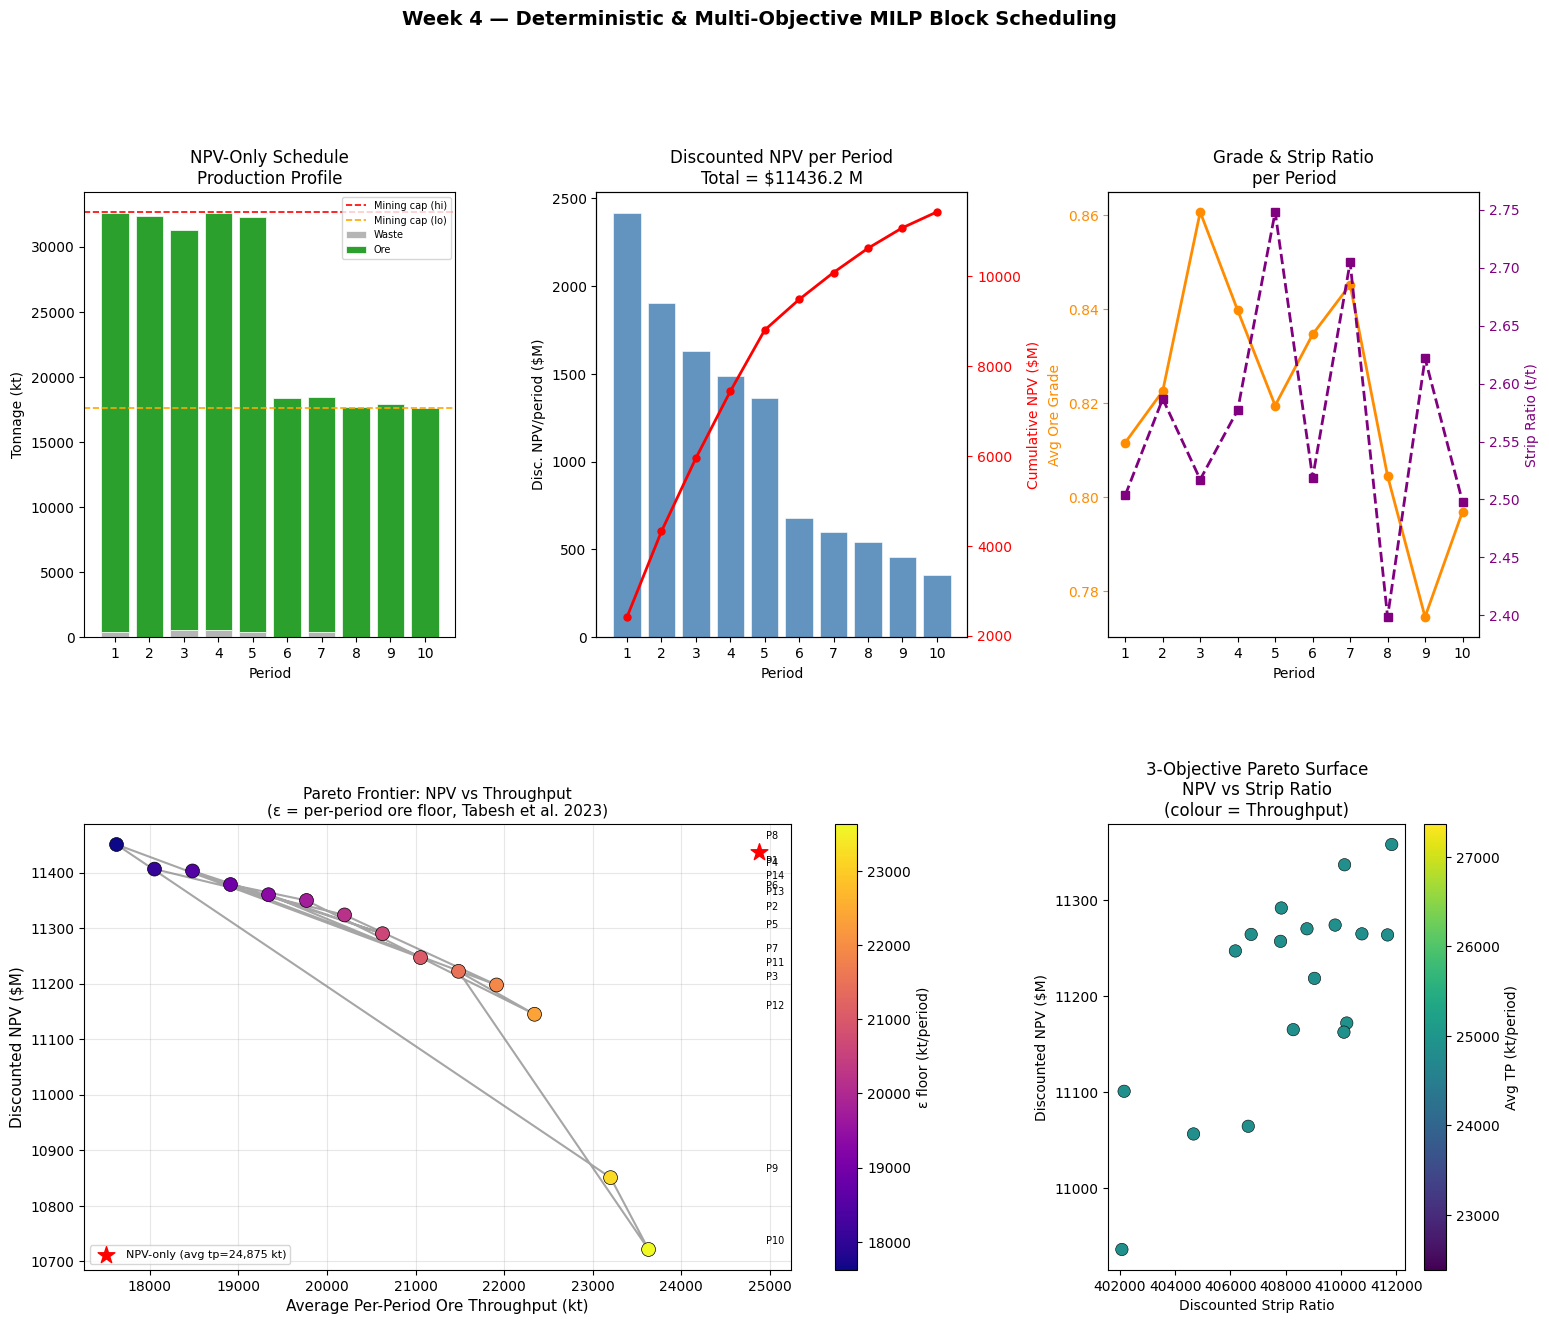

Figure saved: week4_moo_plots.png


In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# Plot 1: Production schedule 
ax1 = fig.add_subplot(gs[0, 0])
bar_waste = period_kpi['tonnage_kt'] - period_kpi['throughput']
bar_ore   = period_kpi['throughput']
ax1.bar(period_kpi['period'], bar_waste, color='#b5b5b5',
        edgecolor='white', linewidth=0.5, label='Waste')
ax1.bar(period_kpi['period'], bar_ore, bottom=bar_waste,
        color='#2ca02c', edgecolor='white', linewidth=0.5, label='Ore')
ax1.axhline(MC_hi, color='red',    linestyle='--', linewidth=1.2, label='Mining cap (hi)')
ax1.axhline(MC_lo, color='orange', linestyle='--', linewidth=1.2, label='Mining cap (lo)')
ax1.set_xlabel('Period'); ax1.set_ylabel('Tonnage (kt)')
ax1.set_title('NPV-Only Schedule\nProduction Profile')
ax1.legend(fontsize=7); ax1.set_xticks(range(1, T+1))

# Plot 2: Discounted NPV per period 
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(period_kpi['period'], period_kpi['disc_npv_M'],
        color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.85)
ax2b = ax2.twinx()
ax2b.plot(period_kpi['period'], period_kpi['cum_disc_npv_M'],
          'r-o', linewidth=2, markersize=5)
ax2.set_xlabel('Period'); ax2.set_ylabel('Disc. NPV/period ($M)')
ax2b.set_ylabel('Cumulative NPV ($M)', color='red')
ax2b.tick_params(axis='y', colors='red')
ax2.set_title(f'Discounted NPV per Period\nTotal = ${obj_npv:.1f} M')
ax2.set_xticks(range(1, T+1))

# Plot 3: Grade & strip ratio per period 
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(period_kpi['period'], period_kpi['avg_grade'], 'o-',
         color='darkorange', linewidth=2, markersize=6, label='Avg grade')
ax3.set_xlabel('Period'); ax3.set_ylabel('Avg Ore Grade', color='darkorange')
ax3.tick_params(axis='y', colors='darkorange')
ax3b = ax3.twinx()
ax3b.plot(period_kpi['period'], period_kpi['avg_sr'], 's--',
          color='purple', linewidth=2, markersize=6, label='Strip ratio')
ax3b.set_ylabel('Strip Ratio (t/t)', color='purple')
ax3b.tick_params(axis='y', colors='purple')
ax3.set_title('Grade & Strip Ratio\nper Period')
ax3.set_xticks(range(1, T+1))

# Plot 4: NPV vs Throughput Pareto frontier 
ax4 = fig.add_subplot(gs[1, 0:2])
if len(pareto_df) > 1:
    # Swap 'avg_tp' for the actual epsilon constraint you swept
    sc4 = ax4.scatter(pareto_df['eps_per_period'], pareto_df['npv_M'],
                      c=pareto_df['eps_per_period'], cmap='plasma',
                      s=100, zorder=5, edgecolors='k', linewidths=0.5)
    
    ax4.plot(pareto_df['eps_per_period'], pareto_df['npv_M'],
             '-', color='gray', linewidth=1.5, zorder=4, alpha=0.7)
    plt.colorbar(sc4, ax=ax4, label='ε floor (kt/period)')
    for i, row in pareto_df.iterrows():
        ax4.annotate(f'P{i+1}', (row['avg_tp'], row['npv_M']),
                     textcoords='offset points', xytext=(5, 4), fontsize=7)
# Mark NPV-only point
ax4.scatter(period_kpi['throughput'].mean(), obj_npv,
            color='red', s=160, zorder=6, marker='*',
            label=f'NPV-only (avg tp={period_kpi["throughput"].mean():,.0f} kt)')
ax4.set_xlabel('Average Per-Period Ore Throughput (kt)', fontsize=11)
ax4.set_ylabel('Discounted NPV ($M)', fontsize=11)
ax4.set_title('Pareto Frontier: NPV vs Throughput\n'
              '(ε = per-period ore floor, Tabesh et al. 2023)', fontsize=11)
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# Plot 5: 3-objective surface 
ax5 = fig.add_subplot(gs[1, 2])
if len(pareto_3df) > 0:
    sc5 = ax5.scatter(pareto_3df['strip_ratio_disc'], pareto_3df['npv_M'],
                      c=pareto_3df['avg_tp'], cmap='viridis',
                      s=80, edgecolors='k', linewidths=0.4)
    plt.colorbar(sc5, ax=ax5, label='Avg TP (kt/period)')
    ax5.set_xlabel('Discounted Strip Ratio')
    ax5.set_ylabel('Discounted NPV ($M)')
    ax5.set_title('3-Objective Pareto Surface\nNPV vs Strip Ratio\n(colour = Throughput)')
else:
    ax5.text(0.5, 0.5, 'No feasible\n3-obj points', ha='center', va='center',
             transform=ax5.transAxes, fontsize=12)
    ax5.set_title('3-Objective: No feasible points')

fig.suptitle('Week 4 — Deterministic & Multi-Objective MILP Block Scheduling',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('week4_moo_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: week4_moo_plots.png')

## 8. KPI Summary Table with Operational Interpretation

In [15]:
npv_undiscounted = sched_npv['npv_exp'].sum()
throughput_total = sched_npv['throughput'].sum()
avg_grade_sched  = sched_npv['grade'].mean()
avg_sr_sched     = sched_npv['strip_ratio'].mean()
n_periods_full   = (period_kpi['tonnage_kt'] >= MC_lo).sum()

if len(pareto_df) > 1:
    npv_range_pct = (pareto_df['npv_M'].max() - pareto_df['npv_M'].min()) / pareto_df['npv_M'].max() * 100
    tp_range_pct  = (pareto_df['avg_tp'].max() - pareto_df['avg_tp'].min()) / pareto_df['avg_tp'].max() * 100
    pareto_pts    = len(pareto_df)
else:
    npv_range_pct = tp_range_pct = 0.0
    pareto_pts    = len(pareto_df)

kpi_data = {
    'KPI': [
        'Total Discounted NPV',
        'Total Undiscounted NPV',
        'NPV Discounting Penalty',
        'Total Ore Throughput (mine life)',
        'Avg Per-Period Ore (NPV-only)',
        'Worst Period Ore (NPV-only)',
        'Average Ore Grade (scheduled)',
        'Average Strip Ratio (scheduled)',
        'Periods at Full Mining Capacity',
        'Solve Time — NPV-only MILP',
        'Pareto Points (2-objective)',
        'NPV Trade-off Across Frontier',
        'Throughput Range Across Frontier',
        '3-Obj Pareto Surface Points',
    ],
    'Value': [
        f'${obj_npv:,.1f} M',
        f'${npv_undiscounted:,.1f} M',
        f'{(1 - obj_npv/npv_undiscounted)*100:.1f}% reduction',
        f'{throughput_total:,.0f} kt ore',
        f'{period_kpi["throughput"].mean():,.0f} kt/period',
        f'{period_kpi["throughput"].min():,.0f} kt/period  (Period {int(period_kpi["throughput"].idxmin()+1)})',
        f'{avg_grade_sched:.3f} fraction',
        f'{avg_sr_sched:.2f} t waste / t ore',
        f'{n_periods_full} / {T}',
        f'{t_npv:.1f} s',
        f'{pareto_pts}',
        f'{npv_range_pct:.2f}% spread  (${pareto_df["npv_M"].max()-pareto_df["npv_M"].min():,.1f}M absolute)',
        f'{tp_range_pct:.2f}% spread',
        f'{len(pareto_3df)}',
    ],
    'Operational Interpretation': [
        'Present-value profit from mine over full 10-year life at 10% discount rate.',
        'Nominal (non-time-adjusted) total profit — shows the raw earnings before discounting.',
        'Value eroded purely by time-value of money; incentivises mining high-NPV blocks early.',
        'Total metal-bearing tonnage delivered to mill over the mine life.',
        'Average mill feed rate per period in the NPV-optimal schedule.',
        'Periods 6–10 are starved by NPV-max; this is the binding constraint for the Pareto sweep.',
        'Higher = richer ore feed; target ±5% of cut-off grade for stable metallurgy.',
        'kt waste per kt ore; lower reduces haulage cost and fleet size.',
        'Periods hitting ≥70% mining capacity; gaps indicate scheduling inflexibility.',
        'CBC at 0.5% MIP gap; production runs use HiGHS/Gurobi for tighter optimality.',
        'Points on NPV–Throughput Pareto front; the decision space available to planners.',
        'How much NPV must be sacrificed to achieve uniform mill throughput.',
        'Range of achievable per-period ore rates while maintaining mine feasibility.',
        'Points on 3-D NPV/Throughput/Strip-Ratio surface for ESG-aware scheduling.',
    ]
}

kpi_df = pd.DataFrame(kpi_data)
print('Week 4 — MILP Block Scheduling KPI Table')
print(kpi_df.to_string(index=False))

Week 4 — MILP Block Scheduling KPI Table
                             KPI                            Value                                                                Operational Interpretation
            Total Discounted NPV                      $11,436.2 M               Present-value profit from mine over full 10-year life at 10% discount rate.
          Total Undiscounted NPV                      $17,036.3 M     Nominal (non-time-adjusted) total profit — shows the raw earnings before discounting.
         NPV Discounting Penalty                  32.9% reduction    Value eroded purely by time-value of money; incentivises mining high-NPV blocks early.
Total Ore Throughput (mine life)                   248,755 kt ore                         Total metal-bearing tonnage delivered to mill over the mine life.
   Avg Per-Period Ore (NPV-only)                 24,875 kt/period                            Average mill feed rate per period in the NPV-optimal schedule.
     Worst Period Ore (

## 9. Export Results

In [16]:
import json

sched_npv.to_csv('week4_npv_schedule.csv', index=False)
print('Saved: week4_npv_schedule.csv')

pareto_df.to_csv('week4_pareto_2obj.csv', index=False)
print('Saved: week4_pareto_2obj.csv')

if len(pareto_3df) > 0:
    pareto_3df.to_csv('week4_pareto_3obj.csv', index=False)
    print('Saved: week4_pareto_3obj.csv')

kpi_df.to_csv('week4_kpi_table.csv', index=False)
print('Saved: week4_kpi_table.csv')

week4_results = {
    'obj_npv_M'             : obj_npv,
    'solve_time_s'           : t_npv,
    'T'                      : T,
    'MC_lo'                  : MC_lo,
    'MC_hi'                  : MC_hi,
    'PC_lo'                  : PC_lo,
    'PC_hi'                  : PC_hi,
    'disc'                   : disc.tolist(),
    'eps_min_per_period'     : float(eps_range[0]),
    'eps_max_per_period'     : float(eps_range[-1]),
    'pareto_2obj_npv'        : pareto_df['npv_M'].tolist(),
    'pareto_2obj_avg_tp'     : pareto_df['avg_tp'].tolist(),
    'pareto_2obj_eps'        : pareto_df['eps_per_period'].tolist(),
}
with open('week4_results.json', 'w') as f:
    json.dump(week4_results, f, indent=2)
print('Saved: week4_results.json  (for Week 5 stochastic comparison)')

Saved: week4_npv_schedule.csv
Saved: week4_pareto_2obj.csv
Saved: week4_pareto_3obj.csv
Saved: week4_kpi_table.csv
Saved: week4_results.json  (for Week 5 stochastic comparison)
